In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../Data/ETHUSDT_1m.csv")

In [5]:
df.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_base,taker_quote,ignore
0,2017-08-17 04:00:00,301.13,301.13,301.13,301.13,0.42643,2017-08-17 04:00:59.999,128.410866,2,0.42643,128.410866,0
1,2017-08-17 04:01:00,301.13,301.13,301.13,301.13,2.75787,2017-08-17 04:01:59.999,830.477393,4,2.75787,830.477393,0
2,2017-08-17 04:02:00,300.00,300.00,300.00,300.00,0.09930,2017-08-17 04:02:59.999,29.790000,2,0.09930,29.790000,0
3,2017-08-17 04:03:00,300.00,300.00,300.00,300.00,0.31389,2017-08-17 04:03:59.999,94.167000,3,0.00000,0.000000,0
4,2017-08-17 04:04:00,301.13,301.13,301.13,301.13,0.23202,2017-08-17 04:04:59.999,69.868183,1,0.23202,69.868183,0


In [17]:
def strategy(df, window=1):
    df = df.copy()

    # Log returns
    df['log_return'] = np.log(df.close.pct_change() + 1)

    # Rolling momentum
    df['prior_log_return_sum'] = df['log_return'].rolling(window=window).sum()

    df.dropna(inplace=True)

    # Long if momentum > 0, short if momentum < 0
    df['position'] = df['prior_log_return_sum'].apply(lambda x: 1 if x > 0 else -1)

    # Strategy return
    df['strat'] = df['position'].shift(1) * df['log_return']

    # Return performance plot
    return np.exp(df[['log_return', 'strat']].cumsum()).plot(figsize=(12,6))


<Axes: >

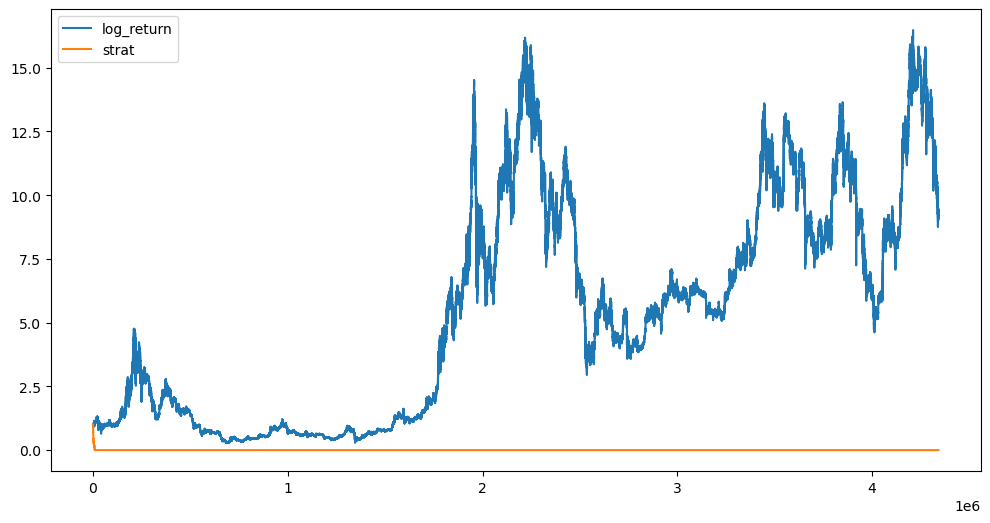

In [23]:
strategy(df, 20)

# This momentum strategy does not work for a few reasons:
# 1. **Transaction Costs:** On a 1-minute timeframe, frequent trading leads to high transaction costs (fees, slippage) that are not included here.
# 2. **Market Noise:** Price action on short intervals like 1 minute is mostly random noise, which makes momentum signals unreliable.